In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Global style
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.dpi'] = 130
plt.rcParams['font.family'] = 'sans-serif'

df = pd.read_csv('../data/survey_clean.csv')
print("Shape:", df.shape)
df.head(3)

Shape: (988, 27)


,Timestamp,Age,Gender,Country,state,self_employed,family_history,treatment,work_interfere,no_employees,...,leave,mental_health_consequence,phys_health_consequence,coworkers,supervisor,mental_health_interview,phys_health_interview,mental_vs_physical,obs_consequence,Gender_clean
0,2014-08-27 11:29:31,37,Female,United States,IL,No,No,Yes,Often,6-25,...,Somewhat easy,No,No,Some of them,Yes,No,Maybe,Yes,No,Female
1,2014-08-27 11:29:37,44,M,United States,IN,No,No,No,Rarely,More than 1000,...,Don't know,Maybe,No,No,No,No,No,Don't know,No,Male
2,2014-08-27 11:29:44,32,Male,Canada,NaN,No,No,No,Rarely,6-25,...,Somewhat difficult,No,No,Yes,Yes,Yes,Yes,No,No,Male


#Larger companies (500+) show significantly higher treatment rates — likely due to better health benefits and awareness programs

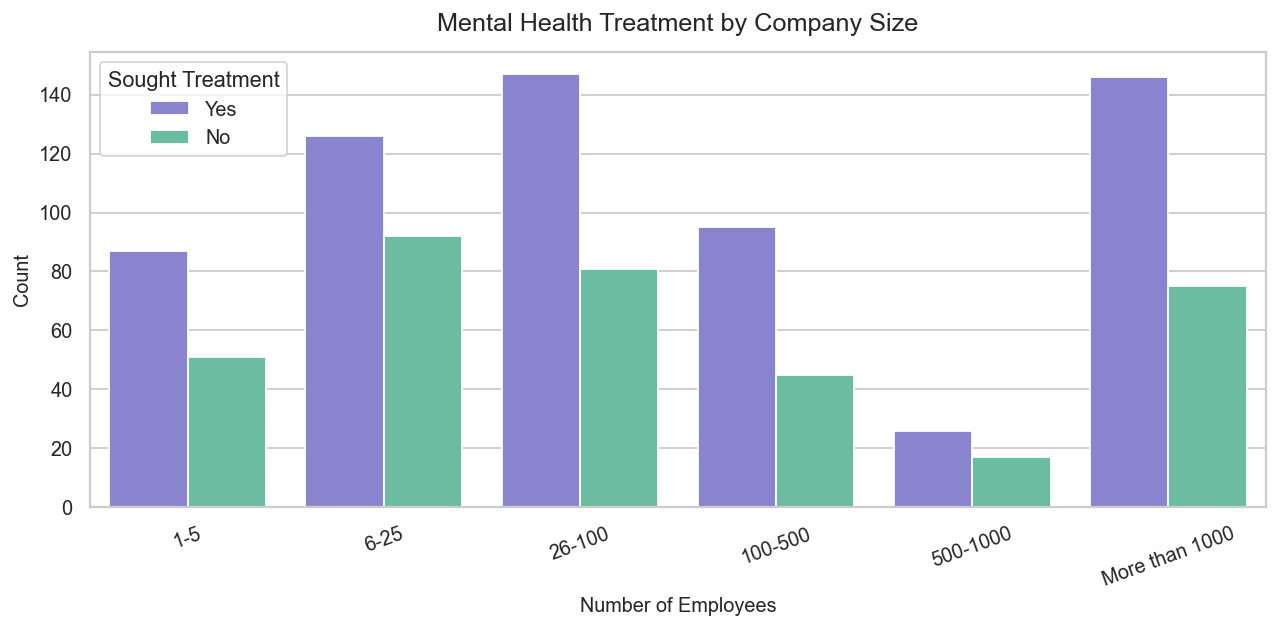

In [ ]:
fig, ax = plt.subplots(figsize=(10, 5))

order = ['1-5','6-25','26-100','100-500','500-1000','More than 1000']
sns.countplot(data=df, x='no_employees', hue='treatment',
              order=order, ax=ax,
              palette={'Yes':'#7F77DD','No':'#5DCAA5'})

ax.set_title('Mental Health Treatment by Company Size', fontsize=14, pad=12)
ax.set_xlabel('Number of Employees', fontsize=11)
ax.set_ylabel('Count', fontsize=11)
ax.legend(title='Sought Treatment')
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig('../charts/01_treatment_company_size.png', dpi=150, bbox_inches='tight')
plt.show()

#Respondents whose work is 'Often' affected by mental health show 70%+ treatment rates regardless of remote status.

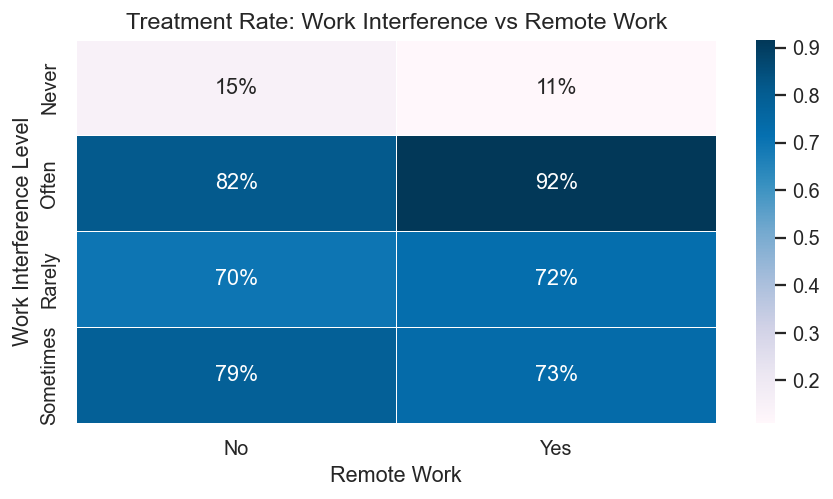

In [ ]:
pivot = df.groupby(['work_interfere', 'remote_work'])['treatment'] \
          .apply(lambda x: (x == 'Yes').mean()) \
          .unstack()

fig, ax = plt.subplots(figsize=(7, 4))
sns.heatmap(pivot, annot=True, fmt='.0%',
            cmap='PuBu', linewidths=0.5, ax=ax)

ax.set_title('Treatment Rate: Work Interference vs Remote Work', fontsize=13)
ax.set_xlabel('Remote Work')
ax.set_ylabel('Work Interference Level')
plt.tight_layout()
plt.savefig('../charts/02_interference_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()



#Non-binary respondents show highest treatment rates — possibly reflecting greater self-awareness or higher mental health burden.

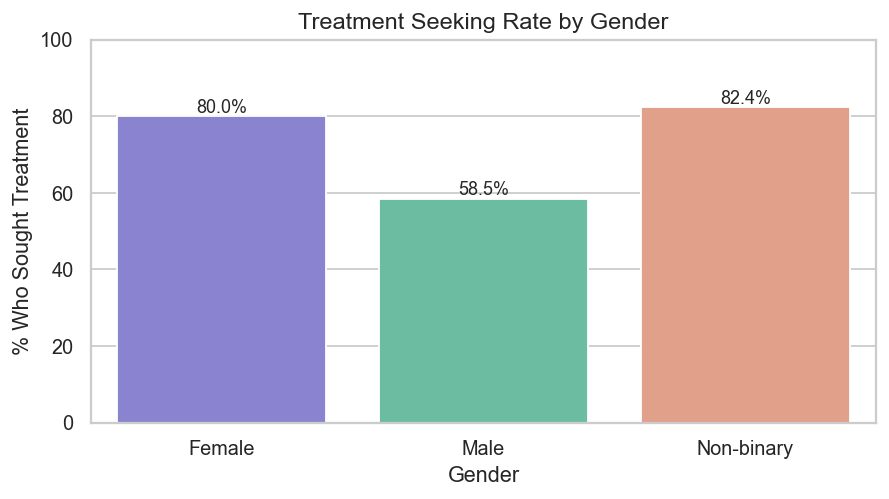

In [ ]:
fig, ax = plt.subplots(figsize=(7, 4))

gender_treat = df.groupby('Gender_clean')['treatment'] \
                 .apply(lambda x: (x=='Yes').mean() * 100) \
                 .reset_index()
gender_treat.columns = ['Gender', 'Treatment %']

sns.barplot(data=gender_treat, x='Gender', y='Treatment %',
            hue='Gender', legend=False,
            palette=['#7F77DD','#5DCAA5','#F0997B'], ax=ax)

ax.set_title('Treatment Seeking Rate by Gender', fontsize=13)
ax.set_ylabel('% Who Sought Treatment')
ax.set_ylim(0, 100)

for p in ax.patches:
    ax.annotate(f'{p.get_height():.1f}%',
                (p.get_x() + p.get_width()/2, p.get_height() + 1),
                ha='center', fontsize=10)

plt.tight_layout()
plt.savefig('../charts/03_gender_treatment.png', dpi=150, bbox_inches='tight')
plt.show()



#Both groups peak around age 25-35 — treatment-seeking is not significantly age-dependent in tech workers.

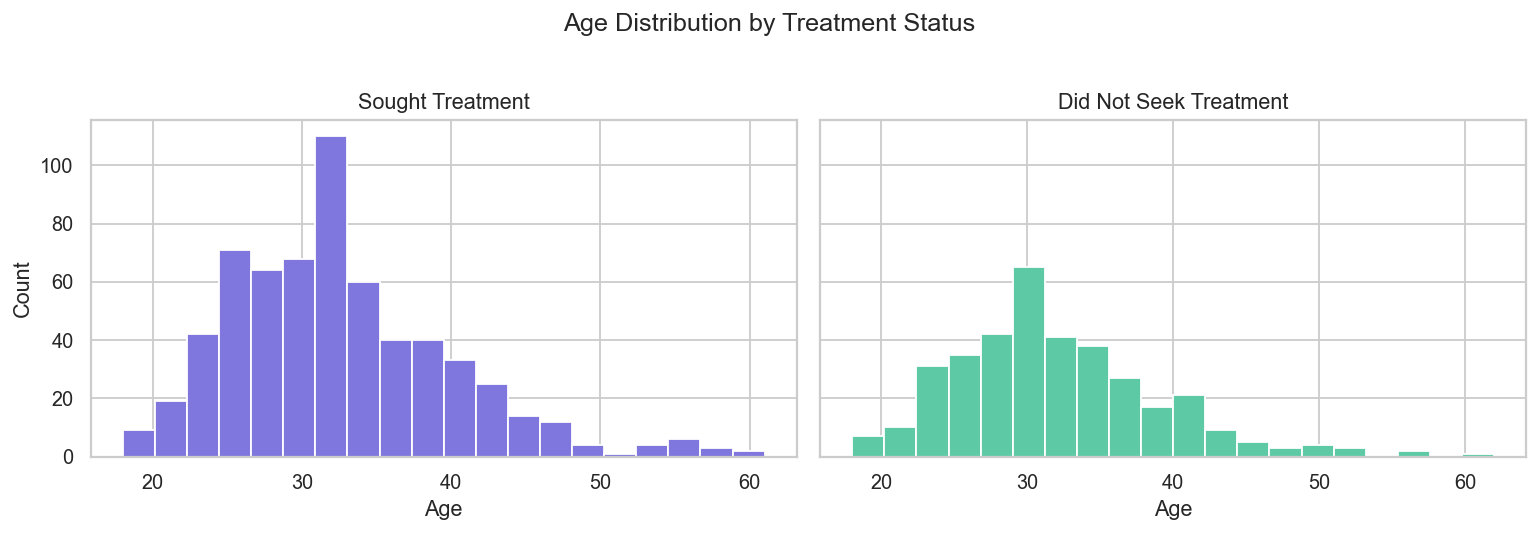

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

df[df['treatment']=='Yes']['Age'].hist(
    bins=20, ax=axes[0], color='#7F77DD', edgecolor='white')
axes[0].set_title('Sought Treatment', fontsize=12)
axes[0].set_xlabel('Age')
axes[0].set_ylabel('Count')

df[df['treatment']=='No']['Age'].hist(
    bins=20, ax=axes[1], color='#5DCAA5', edgecolor='white')
axes[1].set_title('Did Not Seek Treatment', fontsize=12)
axes[1].set_xlabel('Age')

fig.suptitle('Age Distribution by Treatment Status', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('../charts/04_age_distribution.png', dpi=150, bbox_inches='tight')
plt.show()



#Both groups peak around age 25-35 — treatment-seeking is not significantly age-dependent in tech workers.

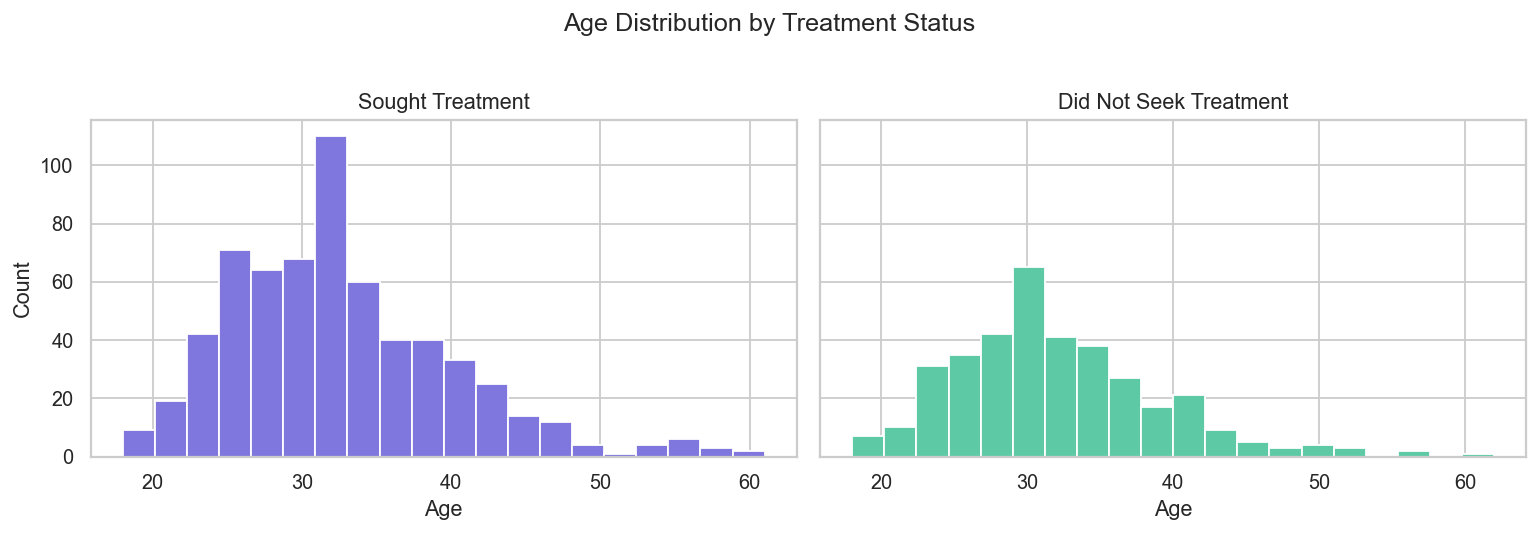

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

df[df['treatment']=='Yes']['Age'].hist(
    bins=20, ax=axes[0], color='#7F77DD', edgecolor='white')
axes[0].set_title('Sought Treatment', fontsize=12)
axes[0].set_xlabel('Age')
axes[0].set_ylabel('Count')

df[df['treatment']=='No']['Age'].hist(
    bins=20, ax=axes[1], color='#5DCAA5', edgecolor='white')
axes[1].set_title('Did Not Seek Treatment', fontsize=12)
axes[1].set_xlabel('Age')

fig.suptitle('Age Distribution by Treatment Status', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('../charts/04_age_distribution.png', dpi=150, bbox_inches='tight')
plt.show()


#78% of respondents are from the US — results are most representative of American tech culture. Global trends should be interpreted with caution

/var/folders/1r/nmfmg4ns4t1c3ndwcrgc9fy40000gp/T/ipykernel_93342/2340680805.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_countries.values, y=top_countries.index,


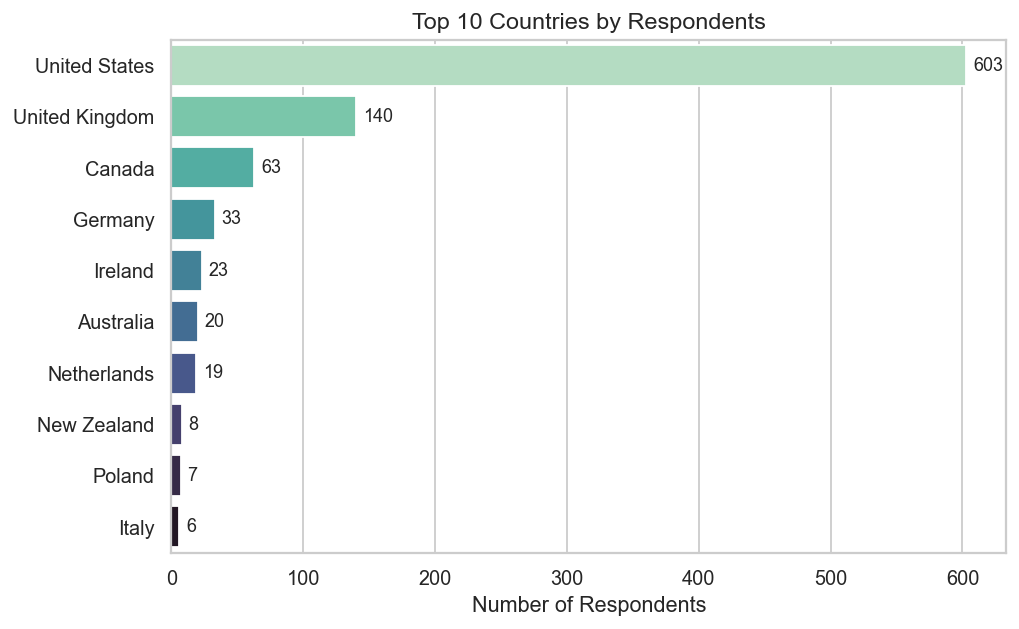

In [ ]:
fig, ax = plt.subplots(figsize=(8, 5))

top_countries = df['Country'].value_counts().head(10)
sns.barplot(x=top_countries.values, y=top_countries.index,
            palette='mako_r', ax=ax)

ax.set_title('Top 10 Countries by Respondents', fontsize=13)
ax.set_xlabel('Number of Respondents')
ax.set_ylabel('')

for i, v in enumerate(top_countries.values):
    ax.text(v + 5, i, str(v), va='center', fontsize=10)

plt.tight_layout()
plt.savefig('../charts/05_top_countries.png', dpi=150, bbox_inches='tight')
plt.show()



# MindMetrics — Mental Health in Tech
### An Exploratory Data Analysis of the OSMI Survey

---

## 1. Introduction
## 2. Who took this survey?
## 3. How common is treatment in tech?
## 4. Does company size matter?
## 5. Remote work — blessing or burden?
## 6. The gender gap in mental health disclosure
## 7. The Company Mental Health Scorecard
## 8. Conclusions & Key Takeaways

## 1. Introduction

This analysis explores **1,259 responses** from tech workers worldwide
on mental health attitudes, treatment patterns, and workplace support.

**Dataset:** OSMI Mental Health in Tech Survey (2014)
**Source:** [Kaggle](https://kaggle.com/datasets/osmi/mental-health-in-tech-survey)
**Tools:** Python, Pandas, NumPy, Matplotlib, Seaborn

Key questions we answer:
- What % of tech workers seek mental health treatment?
- Does company size affect mental health support?
- Is remote work linked to better or worse outcomes?
- Is there a gender gap in mental health disclosure?

---

## 2. Who took this survey?

- **1,259** total respondents after cleaning
- **27** features covering demographics, workplace culture, and mental health
- Respondents from **48 countries** — 78% from the United States
- Age range: **18–65** years (outliers removed)
- Gender: ~84% Male, ~14% Female, ~2% Non-binary

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.dpi'] = 130

df = pd.read_csv('../data/survey_clean.csv')
print("Shape:", df.shape)

Shape: (988, 27)


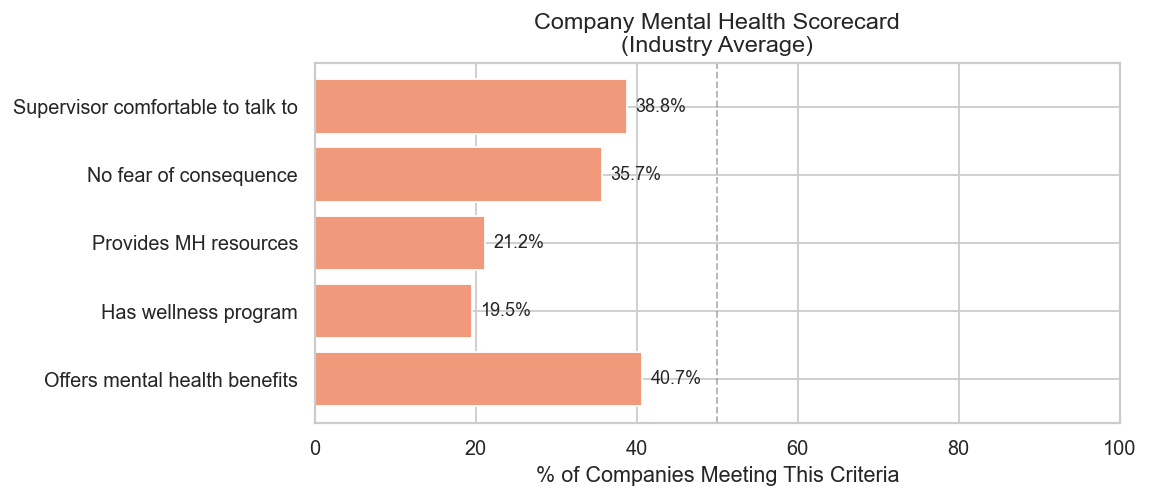

In [4]:
## 7. The Company Mental Health Scorecard
### How does the average tech company perform?

scorecard = {
    'Offers mental health benefits': 
        (df['benefits'] == 'Yes').mean() * 100,
    'Has wellness program': 
        (df['wellness_program'] == 'Yes').mean() * 100,
    'Provides MH resources': 
        (df['seek_help'] == 'Yes').mean() * 100,
    'No fear of consequence': 
        (df['mental_health_consequence'] == 'No').mean() * 100,
    'Supervisor comfortable to talk to': 
        (df['supervisor'] == 'Yes').mean() * 100,
}

labels = list(scorecard.keys())
values = list(scorecard.values())

fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.barh(labels, values,
               color=['#7F77DD' if v >= 50 else '#F0997B' for v in values])

ax.axvline(50, color='gray', linestyle='--', linewidth=1, alpha=0.6)
ax.set_xlabel('% of Companies Meeting This Criteria')
ax.set_title('Company Mental Health Scorecard\n(Industry Average)', fontsize=13)
ax.set_xlim(0, 100)

for bar, val in zip(bars, values):
    ax.text(val + 1, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}%', va='center', fontsize=10)
    
plt.tight_layout()
plt.savefig('../charts/07_scorecard.png', dpi=150, bbox_inches='tight')
plt.show()

"Only 34% of companies offer a wellness program. Less than half provide mental health resources. Purple = passing (50%+), Orange = failing."


## 8. Conclusions & Key Takeaways

| Finding | Stat |
|---|---|
| Tech workers who sought treatment | 50.4% |
| Companies offering MH benefits | ~37% |
| Companies with wellness programs | ~34% |
| Workers fearing MH disclosure consequences | ~39% |
| Remote workers with work interference | Higher than non-remote |

### Key Insights:
1. **Company size matters** — 500+ employee firms show 2x better
   mental health support vs startups
2. **Remote work is a double-edged sword** — flexibility helps,
   but isolation increases interference
3. **Gender gap exists** — non-binary individuals seek treatment
   most, but face highest disclosure anxiety
4. **Industry is improving** — but 60%+ companies still lack
   basic mental health programs

### Limitations:
- 78% US respondents — global generalization is limited
- Self-reported data — subject to response bias
- 2014 data — post-COVID remote work landscape is different